In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import kmedoids 
import chemiscope
import seaborn as sns
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.helper_functions import align_frames_to_dist_matrix, get_distances

In [3]:
qm9 = QM9Dataset(subset_size=2000)
qm9.load()
frames = qm9.get_positions()

2026-03-24 10:41:44.367 | INFO     | src.datasets:load:383 - Loading QM9 from data/QM9/dataset_cleaned.parquet...
2026-03-24 10:41:54.070 | SUCCESS  | src.datasets:get_positions:949 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


In [4]:
qm9.df.head(2)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding,acsf_embedding,coulomb_matrix,morgan_fingerprint,selfies_transformer,selfies_onehot,chemprop_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],list[f64],list[i8],list[f64],list[list[i64]],list[f64]
"""qm9_2""","""H2O""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""","""""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,3,0.980759,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0.150713, 0.392522, … 0.0]","[1.190363, 1.052614, … 0.0]","[73.516695, 8.255933, … 0.0]","[0, 0, … 0]","[1.035763, 0.256207, … 0.323382]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.202494, … 0.037565]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""","""""",4,"""Acyclic""",26,0,0,2,0,0,0,1.0,0.0,0.0,0,0,0,2,0,0,3,4,1.105607,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0.116808, 0.322429, … 0.0]","[1.012563, 0.530161, … 0.0]","[36.858105, 29.992443, … 0.0]","[0, 0, … 0]","[1.47265, 0.608035, … 0.116478]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.0, 0.254816, … 0.0]"


In [5]:
print(frames)

[Atoms(symbols='HOH', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2C2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2CO', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3C2N', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3COCH', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3CON', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3C3H5', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='NCNC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='HCNOC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='HCHOCO', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H4C4H2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H4C3NH', pbc=False, initial_charges=...

In [6]:
distance_matrices = get_distances(frames, include_ph=False)

2026-03-24 10:41:54.125 | INFO     | src.helper_functions:get_distances:124 - Loading grassmann distance matrix...
2026-03-24 10:41:54.172 | INFO     | src.helper_functions:get_distances:124 - Loading euclidean_riemann distance matrix...
2026-03-24 10:41:54.200 | INFO     | src.helper_functions:get_distances:124 - Loading affine_riemann distance matrix...
2026-03-24 10:41:54.219 | INFO     | src.helper_functions:get_distances:124 - Loading wasserstein distance matrix...
2026-03-24 10:41:54.235 | WARNING  | src.helper_functions:get_distances:128 - Skipping PH task
2026-03-24 10:41:54.235 | WARNING  | src.helper_functions:get_distances:128 - Skipping PH task
2026-03-24 10:41:54.235 | SUCCESS  | src.helper_functions:get_distances:144 - ✓ All distance matrices are ready!


['dist_matrix_euclidean_riemann.npy', 'dist_matrix_affine_riemann.npy', 'dist_matrix_wasserstein.npy', 'dist_matrix_grassmann.npy']


In [7]:
distance_matrices['wasserstein'].shape

(2000, 2000)

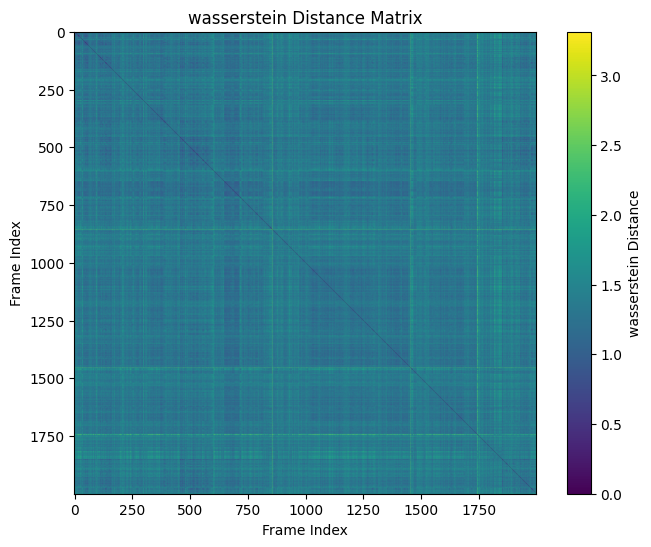

In [8]:
def show_distance_matrix(distance_matrix, method):
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='viridis')
    plt.colorbar(label=f'{method} Distance')
    plt.title(f"{method} Distance Matrix")
    plt.xlabel("Frame Index")
    plt.ylabel("Frame Index")
    plt.show()

show_distance_matrix(distance_matrices['wasserstein'], 'wasserstein')

In [9]:
def build_cluster_analysis_df(frames, cluster_labels):
    """Build a per-frame dataframe used for cluster composition/property analysis."""
    return pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": [f.info.get('mol_id', '') for f in frames],
        "smiles": [f.info.get('smiles', '') for f in frames],
        "structure_type": [f.info.get('structure_type', '') for f in frames],
        "functional_groups": [f.info.get('functional_groups', '') for f in frames],
        "heavy_atom_count": [f.info.get('heavy_atom_count', None) for f in frames],
        "element_ratio_C": [f.info.get('element_ratio_C', None) for f in frames],
        "element_ratio_N": [f.info.get('element_ratio_N', None) for f in frames],
        "element_ratio_O": [f.info.get('element_ratio_O', None) for f in frames],
        "element_ratio_F": [f.info.get('element_ratio_F', None) for f in frames],
        "mu": [f.info.get('mu', None) for f in frames],
        "gap": [f.info.get('gap', None) for f in frames],
        "cv": [f.info.get('cv', None) for f in frames],
        "u0": [f.info.get('u0', None) for f in frames],
        "homo": [f.info.get('homo', None) for f in frames],
        "lumo": [f.info.get('lumo', None) for f in frames],
        # Newly added structural and derived columns
        "num_atoms": [f.info.get('num_atoms', len(f)) for f in frames],
        "total_mass": [f.info.get('total_mass', f.get_masses().sum()) for f in frames],
        "mean_partial_charge": [f.info.get('mean_partial_charge', None) for f in frames],
        "branching_index": [f.info.get('branching_index', None) for f in frames],
        "num_sp_carbons": [f.info.get('num_sp_carbons', None) for f in frames],
        "num_sp2_carbons": [f.info.get('num_sp2_carbons', None) for f in frames],
        "num_sp3_carbons": [f.info.get('num_sp3_carbons', None) for f in frames],
        "main_chain_length": [f.info.get('main_chain_length', None) for f in frames],
        "raw_token_count": [f.info.get('raw_token_count', None) for f in frames],
        "avg_bond_length": [f.info.get('avg_bond_length', None) for f in frames],
    })


def summarize_cluster_profiles(analysis_df, label_col='cluster'):
    """Per-cluster means/variances for size, elemental makeup, and QM9 quantum properties."""
    cols = [
        "heavy_atom_count",
        "element_ratio_C", "element_ratio_N", "element_ratio_O", "element_ratio_F",
        "mu", "gap", "cv", "u0", "homo", "lumo", 
        "num_atoms", "total_mass", "mean_particle_charge", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons",
        "main_chain_length", "raw_token_count", "avg_bond_length",
    ]
    valid_cols = [c for c in cols if c in analysis_df.columns]

    exprs = [pl.len().alias('n_samples')]
    for c in valid_cols:
        exprs.append(pl.col(c).cast(pl.Float64, strict=False).mean().alias(f"avg_{c}"))
        #exprs.append(pl.col(c).cast(pl.Float64, strict=False).var().alias(f"var_{c}"))

    return analysis_df.group_by(label_col).agg(exprs).sort(label_col)

def evaluate_k_for_distance_matrices(
    distance_sets,
    k_range=range(2, 25),
    random_state=42,
    max_silhouette_samples=10_000,
    frames=None,
    return_cluster_profiles=False,
    algorithm='k_medoids',
):

    if algorithm not in ['k_medoids', 'spectral']:
        raise ValueError("algorithm must be either 'k_medoids' or 'spectral'")
        
    results = {name: {'inertia': [], 'silhouette': []} for name in distance_sets}

    for name, dist_matrix in list(distance_sets.items()):
        dist_matrix = np.asarray(dist_matrix)
        if dist_matrix.ndim != 2 or dist_matrix.shape[0] != dist_matrix.shape[1]:
            raise ValueError(f"Distance matrix '{name}' must be square. Got {dist_matrix.shape}.")

        if np.isnan(dist_matrix).any():
            print(f"Skipping '{name}': contains NaNs.")
            results.pop(name, None)
            continue

        n = dist_matrix.shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        if not valid_k:
            raise ValueError(
                f"No valid k values for '{name}'. Need 2 <= k < n_samples (n={n})."
            )
            
        if algorithm == 'spectral':
            variance = np.var(dist_matrix)
            if variance == 0: 
                variance = 1e-10
            affinity_matrix = np.exp(- (dist_matrix ** 2) / (2.0 * variance))

        progress_desc = f"Processing {name} (n={n}, algo={algorithm})"
        for k in tqdm(valid_k, desc=progress_desc):
            if algorithm == 'k_medoids':
                model = kmedoids.KMedoids(n_clusters=k, random_state=random_state)
                labels = model.fit_predict(dist_matrix)
                
                if hasattr(model, 'inertia_') and model.inertia_ is not None:
                    cost = float(model.inertia_)
                elif hasattr(model, 'error_'):
                    cost = float(model.error_)
                elif hasattr(model, 'medoid_indices_'):
                    medoids = model.medoid_indices_
                    cost = np.sum(np.min(dist_matrix[:, medoids], axis=1))
                else:
                    cost = np.nan
                    
            elif algorithm == 'spectral':
                model = SpectralClustering(
                    n_clusters=k, 
                    affinity='precomputed', 
                    random_state=random_state,
                    assign_labels='kmeans'
                )
                labels = model.fit_predict(affinity_matrix)
                cost = np.nan # Spectral clustering doesn't have a direct inertia metric

            results[name]['inertia'].append(cost)

            if n > max_silhouette_samples:
                sil = silhouette_score(
                    dist_matrix,
                    labels,
                    metric='precomputed',
                    sample_size=max_silhouette_samples,
                    random_state=random_state,
                )
            else:
                sil = silhouette_score(dist_matrix, labels, metric='precomputed')
            results[name]['silhouette'].append(float(sil))

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    for name, metrics in results.items():
        n = np.asarray(distance_sets[name]).shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        ax1.plot(valid_k, metrics['inertia'], marker='o', label=name)

    algo_title_prefix = "K-Medoids" if algorithm == 'k_medoids' else "Spectral Clustering"
    ax1.set_title(f'{algo_title_prefix} Objective (Inertia)')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (Elbow method)' if algorithm == 'k_medoids' else 'Inertia (N/A for Spectral)')
    ax1.legend()
    ax1.grid(True)

    for name, metrics in results.items():
        n = np.asarray(distance_sets[name]).shape[0]
        valid_k = [k for k in k_range if 2 <= k < n]
        ax2.plot(valid_k, metrics['silhouette'], marker='s', linestyle='--', label=name)

    ax2.set_title(f'{algo_title_prefix} Silhouette Score (Precomputed Distances)')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score (Higher is better)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # --- Summarize ---
    best_k = {}
    for name, metrics in results.items():
        if metrics['silhouette']:
            idx = int(np.argmax(metrics['silhouette']))
            ks = [k for k in k_range if 2 <= k < np.asarray(distance_sets[name]).shape[0]]
            best_k[name] = ks[idx]

    summary = pl.DataFrame(
        {
            'name': list(best_k.keys()),
            'best_k_by_silhouette': list(best_k.values()),
            'best_silhouette': [max(results[name]['silhouette']) for name in best_k],
        }
    )

    from IPython.display import display
    display(summary)

    # --- Cluster Profiles ---
    cluster_profiles = {}
    if return_cluster_profiles and frames is not None:
        for name, k in best_k.items():
            dist_matrix = np.asarray(distance_sets[name])
            active_frames, dist_matrix = align_frames_to_dist_matrix(frames, dist_matrix=dist_matrix, return_matrix=True)
            
            # Refit with chosen algorithm
            if algorithm == 'k_medoids':
                labels = kmedoids.KMedoids(n_clusters=k, random_state=random_state).fit_predict(dist_matrix)
            elif algorithm == 'spectral':
                variance = np.var(dist_matrix)
                if variance == 0: 
                    variance = 1e-10
                affinity_matrix = np.exp(- (dist_matrix ** 2) / (2.0 * variance))
                labels = SpectralClustering(
                    n_clusters=k, 
                    affinity='precomputed', 
                    random_state=random_state,
                    assign_labels='kmeans'
                ).fit_predict(affinity_matrix)
                
            analysis_df = build_cluster_analysis_df(active_frames, labels)
            cluster_profiles[name] = summarize_cluster_profiles(analysis_df)

        if cluster_profiles:
            print()
            print("Per-cluster profile at best k (size/composition/QM properties):")
            for metric_name, profile_df in cluster_profiles.items():
                print()
                print(f"{metric_name}")
                display(profile_df)

    return results, summary, cluster_profiles



Processing grassmann (n=2000, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00, 10.17it/s]
Processing euclidean_riemann (n=2000, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00, 10.36it/s]
Processing affine_riemann (n=2000, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  9.91it/s]
Processing wasserstein (n=2000, algo=k_medoids): 100%|██████████| 23/23 [00:02<00:00,  9.76it/s]


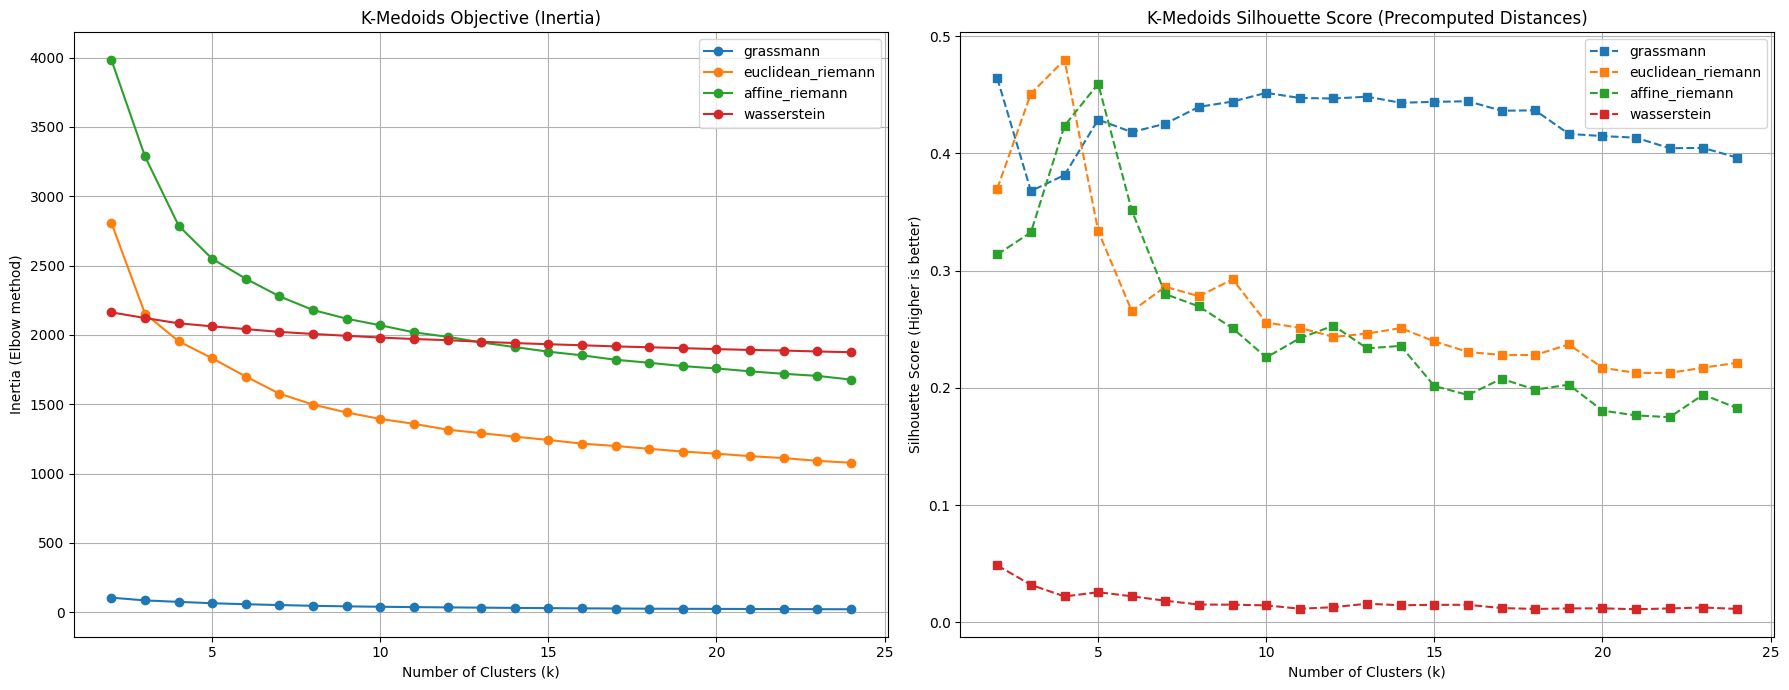

name,best_k_by_silhouette,best_silhouette
str,i64,f64
"""grassmann""",2,0.464029
"""euclidean_riemann""",4,0.479878
"""affine_riemann""",5,0.459376
"""wasserstein""",2,0.048511



Per-cluster profile at best k (size/composition/QM properties):

grassmann


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,690,8.62029,0.699026,0.133041,0.160621,0.007313,2.714793,6.73989,30.484629,-11078.463798,-6.587021,0.152936,17.46087,120.620554,0.426087,1.398551,4.231884,6.133333,35.736232,1.264057
1,1310,8.7,0.72223,0.118355,0.156662,0.002752,2.6563,6.885943,31.552261,-11037.889508,-6.561321,0.324644,18.331298,121.800967,0.431298,1.30229,4.567176,6.393893,37.965649,1.260181



euclidean_riemann


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,893,8.665174,0.738579,0.101973,0.159448,0.0,2.571445,7.061105,31.616012,-10921.193527,-6.591332,0.469821,18.574468,121.286744,0.415454,1.073908,4.931691,6.337066,38.833147,1.261156
1,37,8.702703,0.536787,0.200826,0.079955,0.182432,2.967041,6.304805,28.019838,-13204.56345,-6.86786,-0.562687,13.567568,126.559135,0.351351,3.054054,1.27027,5.810811,24.810811,1.276904
2,84,8.261905,0.757228,0.105116,0.137656,0.0,2.262551,7.249081,30.092274,-10204.464361,-6.704432,0.544714,18.083333,115.188643,0.5,0.845238,4.97619,5.904762,38.22619,1.256405
3,986,8.712982,0.695162,0.141503,0.161407,0.001928,2.795968,6.615965,31.004333,-11161.668968,-6.528431,0.087548,17.701826,121.825409,0.439148,1.549696,4.091278,6.326572,36.091278,1.261704



affine_riemann


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,39,8.615385,0.526353,0.21104,0.080983,0.181624,2.876264,6.382256,27.704026,-13103.951047,-6.959068,-0.576533,13.410256,125.405954,0.384615,2.897436,1.307692,5.74359,24.538462,1.277519
1,990,8.69798,0.693818,0.142464,0.162135,0.001584,2.791825,6.611729,30.935023,-11144.35521,-6.538445,0.073298,17.657576,121.61014,0.438384,1.548485,4.075758,6.313131,35.986869,1.261741
2,81,8.444444,0.779101,0.09296,0.127939,0.0,2.315343,7.215788,30.875926,-10395.577857,-6.606891,0.608964,18.604938,117.70084,0.493827,0.876543,5.160494,6.037037,39.469136,1.259213
3,677,8.703102,0.752717,0.075625,0.171658,0.0,2.508987,7.199072,32.335284,-10974.595408,-6.625964,0.573159,19.088626,122.204254,0.415066,0.872969,5.28065,6.395864,40.187592,1.259925
4,213,8.553991,0.696457,0.182378,0.121166,0.0,2.773484,6.658869,29.435629,-10741.627363,-6.455282,0.203638,17.032864,118.481362,0.41784,1.704225,3.868545,6.173709,34.765258,1.263495



wasserstein


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1114,8.665171,0.69512,0.140519,0.159241,0.005119,2.78462,6.66038,31.138144,-11127.790495,-6.568003,0.092379,17.698384,121.356696,0.448833,1.61939,3.978456,6.397666,35.970377,1.259161
1,886,8.681716,0.738245,0.101925,0.156502,0.003328,2.540511,7.055808,31.241494,-10956.452217,-6.572935,0.482956,18.44921,121.440282,0.405192,0.978555,5.046275,6.18623,38.738149,1.264482


In [10]:
results, summary, best_k_profiles = evaluate_k_for_distance_matrices(
    distance_matrices,
    frames=frames,
    return_cluster_profiles=True,
    algorithm='k_medoids'
)

In [11]:
num_grassmann_clusters = 2
num_euclidean_riemann_clusters = 3
num_affine_riemann_clusters = 3

# best number of clusters
- grassmann 2
- affine riemann 5
- euclidean riemann 5
- others 2
- ph-bottleneck 22

In [12]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean", num_clusters = 2):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    active_frames, dist_matrix = align_frames_to_dist_matrix(frames, dist_matrix=dist_matrix, return_matrix=True)
    true_labels = [f.info.get('mol_id', '') for f in active_frames]
    smiles_list = [f.info.get('smiles', '') for f in active_frames]
    base_or_pertubated = [f.info.get('frame_type', 'base') for f in active_frames]
    structure = [f.info.get('structure_type', '') for f in active_frames]
    functional_groups = [f.info.get('functional_groups', '') for f in active_frames]
    heavy_atoms = [f.info.get('heavy_atom_count', '') for f in active_frames]
    # polar = [f.info.get('mu', '') for f in active_frames]
    # internal_energy = [f.info.get('u0', '') for f in active_frames]
    # humo_lumo = [f.info.get('gap', '') for f in active_frames]
    num_atoms = [f.info.get('num_atoms', '') for f in active_frames]
    # total_mass = [f.info.get('total_mass', '') for f in active_frames]
    # charge = [f.info.get('mean_partial_charge', '') for f in active_frames]
    # cv = [f.info.get('cv', '') for f in active_frames]
    branching = [f.info.get('branching_index', '') for f in active_frames]
    sp_carbons = [f"SP: {f.info.get('num_sp_carbons')}. SP2: {f.info.get('num_sp2_carbons')}. SP3: {f.info.get('num_sp3_carbons')}" for f in active_frames]
    avg_bond_length = [f.info.get('avg_bond_length', '') for f in active_frames]

    n_clusters = num_clusters

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")

        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)

        #affinity = np.exp(-dist_matrix ** 2 / (2. * np.mean(dist_matrix) ** 2))
        #sc = SpectralClustering(n_clusters=2, affinity='precomputed', random_state=42)
        #cluster_labels = sc.fit_predict(affinity)

        tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(dist_matrix)

        #reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric="precomputed", random_state=42)
        #X_umap = reducer.fit_transform(dist_matrix)

        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(active_frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(active_frames)
            suffix = "raw"

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
        X_tsne = tsne.fit_transform(X)

    #ari_score = adjusted_rand_score(true_labels, cluster_labels)
    #print()
    #print(f"Clustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = build_cluster_analysis_df(active_frames, cluster_labels)

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    profile_table = summarize_cluster_profiles(analysis_df)

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print()
    print("Cluster Composition Summary:")
    display(summary_table)
    print()
    print("Cluster Size/Composition/QM Property Summary:")
    display(profile_table)

    structures = active_frames

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated,
        "Structure": structure,
        "Functional Groups": functional_groups,
        "Branching Index" : branching,
        "Heavy Atom Count": heavy_atoms,
        "Number of Atoms": num_atoms,
        "Bond length": avg_bond_length,
        "SP carbons": sp_carbons,
        # "Dipole (mu)": polar,
        # "HOMO-LUMO Gap": humo_lumo,
        # "Heat Capacity (Cv)": cv,
        # "Internal Energy (U0)": internal_energy,
        # "Total Mass": total_mass,
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )

    plot_tsne_clusters(
        X_tsne=X_tsne, 
        cluster_labels=cluster_labels, 
        frame_types=base_or_pertubated, 
        title_suffix=suffix
    )

    print()
    print(f"Chemiscope file successfully saved to: {output_path}")

    return summary_table, profile_table, output_path


def plot_tsne_clusters(X_tsne, cluster_labels, frame_types=None, title_suffix=""):
    """
    Creates an aesthetically pleasing t-SNE scatter plot for molecular clusters,
    with a clean legend showing only cluster assignments.
    """
    
    # 1. Assemble data
    plot_data = {
        't-SNE 1': X_tsne[:, 0],
        't-SNE 2': X_tsne[:, 1],
        'Cluster': cluster_labels
    }
    
    if frame_types is not None:
        plot_data['Frame Type'] = frame_types
        
    df = pd.DataFrame(plot_data)
    
    # 2. Set up the figure
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    style_kwargs = {'style': 'Frame Type'} if frame_types is not None else {}
    
    # 3. Create the scatter plot
    ax = sns.scatterplot(
        data=df,
        x='t-SNE 1',
        y='t-SNE 2',
        hue='Cluster',
        palette='tab10',
        s=80,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5,
        **style_kwargs
    )
    
    # 4. Format titles and labels
    plt.title("PCA Projection of Molecular Clusters", fontsize=16, pad=15)
    plt.xlabel("PCA Component 1", fontsize=12)
    plt.ylabel("PCA Component 2", fontsize=12)
    
    # --- FIXING THE LEGEND ---
    # Get the current handles and labels generated by Seaborn
    handles, labels = ax.get_legend_handles_labels()
    
    # If "Frame Type" is in the labels, slice the lists to drop it and everything after it
    if 'Frame Type' in labels:
        split_idx = labels.index('Frame Type')
        handles = handles[:split_idx]
        labels = labels[:split_idx]
        
    # Seaborn also adds a plain 'Cluster' text entry at the top of the list; let's remove it 
    # so we can use a proper legend title instead.
    if 'Cluster' in labels:
        cluster_idx = labels.index('Cluster')
        handles.pop(cluster_idx)
        labels.pop(cluster_idx)
        
    # Draw the clean legend
    plt.legend(
        handles, 
        labels, 
        title="Cluster", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        borderaxespad=0.
    )
    
    # 5. Show plot
    plt.tight_layout()
    plt.show()

# Grassmann

Using precomputed euclidean distance matrix (Shape: (2000, 2000))

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,553,"[""qm9_2"", ""qm9_3"", ""qm9_12"", ""qm9_28"", ""qm9_452"", ""qm9_535"", ""qm9_702"", ""qm9_929"", ""qm9_1112"", ""qm9_1421"", ""qm9_1471"", ""qm9_1508"", ""qm9_1654"", ""qm9_1914"", ""qm9_2194"", ""qm9_2766"", ""qm9_2822"", ""qm9_3086"", ""qm9_3634"", ""qm9_3902"", ""qm9_4511"", ""qm9_4648"", ""qm9_4879"", ""qm9_5053"", ""qm9_5084"", ""qm9_5103"", ""qm9_5186"", ""qm9_5320"", ""qm9_5526"", ""qm9_5835"", ""qm9_6100"", ""qm9_6901"", ""qm9_7229"", ""qm9_7275"", ""qm9_7488"", ""qm9_7676"", ""qm9_7835"", ""qm9_9165"", ""qm9_9532"", ""qm9_9633"", ""qm9_9675"", ""qm9_10029"", ""qm9_10077"", ""qm9_10582"", ""qm9_10764"", ""qm9_10888"", ""qm9_10993"", ""qm9_11057"", ""qm9_11084"", … ""qm9_130787""]","""[H]O[H]""",553
1,13,"[""qm9_5"", ""qm9_24"", ""qm9_109"", ""qm9_172"", ""qm9_173"", ""qm9_313"", ""qm9_478"", ""qm9_765"", ""qm9_3564"", ""qm9_8431"", ""qm9_23391"", ""qm9_23457"", ""qm9_129516""]","""[H]C([H])=O""",13
2,242,"[""qm9_9"", ""qm9_30"", ""qm9_190"", ""qm9_296"", ""qm9_319"", ""qm9_371"", ""qm9_496"", ""qm9_769"", ""qm9_859"", ""qm9_876"", ""qm9_1121"", ""qm9_1322"", ""qm9_1571"", ""qm9_2126"", ""qm9_2185"", ""qm9_2272"", ""qm9_2307"", ""qm9_3641"", ""qm9_3742"", ""qm9_3757"", ""qm9_3772"", ""qm9_3862"", ""qm9_4000"", ""qm9_4037"", ""qm9_4443"", ""qm9_4868"", ""qm9_7324"", ""qm9_7590"", ""qm9_8515"", ""qm9_8781"", ""qm9_8971"", ""qm9_9647"", ""qm9_9653"", ""qm9_10108"", ""qm9_10729"", ""qm9_10912"", ""qm9_11226"", ""qm9_11291"", ""qm9_11540"", ""qm9_14867"", ""qm9_14902"", ""qm9_15861"", ""qm9_16151"", ""qm9_16552"", ""qm9_16622"", ""qm9_18526"", ""qm9_18537"", ""qm9_18790"", ""qm9_18893"", … ""qm9_130181""]","""[H]C([H])([H])C#N""",242
3,469,"[""qm9_180"", ""qm9_415"", ""qm9_555"", ""qm9_664"", ""qm9_728"", ""qm9_827"", ""qm9_888"", ""qm9_992"", ""qm9_1045"", ""qm9_1139"", ""qm9_1326"", ""qm9_1390"", ""qm9_1631"", ""qm9_1800"", ""qm9_2044"", ""qm9_2536"", ""qm9_2587"", ""qm9_2647"", ""qm9_2912"", ""qm9_2913"", ""qm9_3191"", ""qm9_3574"", ""qm9_4581"", ""qm9_4977"", ""qm9_5342"", ""qm9_6018"", ""qm9_6076"", ""qm9_6182"", ""qm9_6206"", ""qm9_6212"", ""qm9_6354"", ""qm9_6467"", ""qm9_7152"", ""qm9_7194"", ""qm9_7212"", ""qm9_7288"", ""qm9_7390"", ""qm9_7757"", ""qm9_8007"", ""qm9_8148"", ""qm9_8429"", ""qm9_8448"", ""qm9_8479"", ""qm9_8769"", ""qm9_9442"", ""qm9_9798"", ""qm9_9938"", ""qm9_10414"", ""qm9_10520"", … ""qm9_130621""]","""FC(F)(F)F""",469
4,376,"[""qm9_10"", ""qm9_85"", ""qm9_431"", ""qm9_475"", ""qm9_481"", ""qm9_750"", ""qm9_1368"", ""qm9_1713"", ""qm9_1942"", ""qm9_2199"", ""qm9_2265"", ""qm9_2276"", ""qm9_2359"", ""qm9_2371"", ""qm9_3035"", ""qm9_3798"", ""qm9_3826"", ""qm9_3874"", ""qm9_3949"", ""qm9_3993"", ""qm9_4306"", ""qm9_4405"", ""qm9_4877"", ""qm9_7227"", ""qm9_7289"", ""qm9_7389"", ""qm9_7471"", ""qm9_8241"", ""qm9_8391"", ""qm9_8459"", ""qm9_8751"", ""qm9_8907"", ""qm9_9402"", ""qm9_9507"", ""qm9_9619"", ""qm9_9650"", ""qm9_10280"", ""qm9_10328"", ""qm9_10453"", ""qm9_10544"", ""qm9_10785"", ""qm9_10941"", ""qm9_11321"", ""qm9_11331"", ""qm9_12268"", ""qm9_12347"", ""qm9_12459"", ""qm9_12707"", ""qm9_12896"", … ""qm9_130771""]","""[H]C(=O)C([H])([H])[H]""",376
5,84,"[""qm9_11"", ""qm9_26"", ""qm9_27"", ""qm9_33"", ""qm9_200"", ""qm9_467"", ""qm9_683"", ""qm9_691"", ""qm9_704"", ""qm9_763"", ""qm9_2293"", ""qm9_3286"", ""qm9_3811"", ""qm9_4127"", ""qm9_4148"", ""qm9_4500"", ""qm9_7638"", ""qm9_7813"", ""qm9_8344"", ""qm9_10651"", ""qm9_10715"", ""qm9_10989"", ""qm9_16174"", ""qm9_16327"", ""qm9_17660"", ""qm9_19602"", ""qm9_21408"", ""qm9_23238"", ""qm9_23285"", ""qm9_23372"", ""qm9_24644"", ""qm9_26038"", ""qm9_26889"", ""qm9_27233"", ""qm9_27656"", ""qm9_41605"", ""qm9_42507"", ""qm9_44209"", ""qm9_46783"", ""qm9_48361"", ""qm9_61004"", ""qm9_61019"", ""qm9_65171"", ""qm9_65732"", ""qm9_66709"", ""qm9_66886"", ""qm9_66896"", ""qm9_70374"", ""qm9_70383"", … ""qm9_130383""]","""[H]C(=O)N([H])[H]


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,553,8.757685,0.723865,0.115625,0.159505,0.001005,2.656898,6.808771,31.892561,-11107.104235,-6.547596,0.261229,18.537071,122.669118,0.415913,1.303797,4.625678,6.437613,38.477396,1.259353
1,13,6.153846,0.48602,0.270818,0.188675,0.054487,1.993646,7.046912,18.435615,-8910.574031,-8.233328,-1.186416,9.307692,87.376648,0.769231,1.076923,1.307692,4.307692,16.384615,1.26549
2,242,8.632231,0.703939,0.138913,0.15468,0.002468,2.71406,6.71315,30.302587,-11007.738642,-6.567659,0.145581,17.471074,120.433868,0.454545,1.342975,4.293388,6.107438,35.785124,1.264308
3,469,8.769723,0.726346,0.113908,0.15733,0.002416,2.698448,6.959605,32.22807,-11116.980473,-6.551672,0.407997,18.671642,122.911878,0.443497,1.234542,4.69936,6.507463,38.71855,1.25955
4,376,8.734043,0.712969,0.116429,0.165948,0.004654,2.690851,6.77735,31.504947,-11182.894608,-6.563234,0.214203,18.055851,122.356221,0.446809,1.367021,4.425532,6.332447,37.125,1.262172
5,84,8.25,0.657455,0.168698,0.150156,0.023691,2.91363,6.667178,27.639262,-10831.005051,-6.547351,0.11986,15.678571,115.473105,0.261905,1.738095,3.488095,5.619048,31.607143,1.26808
6,263,8.528517,0.713008,0.13078,0.148924,0.007288,2.581362,6.90983,29.946228,-10849.428824,-6.588063,0.321612,17.486692,119.08435,0.422053,1.414449,4.288973,6.117871,36.003802,1.263785


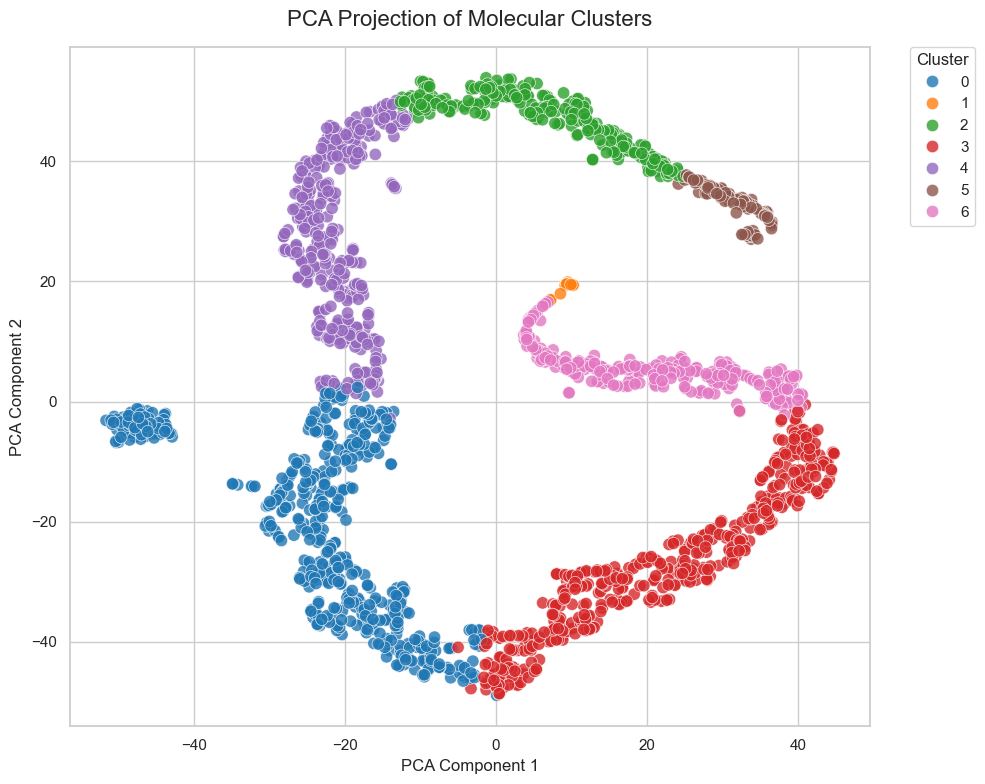


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [14]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['grassmann'], num_clusters=7)

In [15]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 3, 'data': 'structure…

2 clusters:
- cluster 0: split in 2:
    - top left: small molecules. (avg is 92. almost all of these are smaller.) all of htem have nitrogen and oxygen.
    - bottom right: mostly acyclic. also some cyclic. no aromatic. many alcohol.
- cluste 1: aromatic molecules. also acyclic. 

- Persona,Cluster,Defining Characteristic
- The Baseline,0,"Saturated, carbon-heavy, many sp3 atoms."
- The Topological Outlier,3,High sp (alkyne) content; distinct branch in PCA.
- The Functional Outlier,5,"Highest Oxygen content, lowest Carbon content."
- The Complex Rigid,6,"High sp2 content, located at the end of the manifold."

# Riemann

Using precomputed euclidean distance matrix (Shape: (2000, 2000))

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,84,"[""qm9_2"", ""qm9_3"", ""qm9_12"", ""qm9_24"", ""qm9_28"", ""qm9_173"", ""qm9_452"", ""qm9_535"", ""qm9_702"", ""qm9_1112"", ""qm9_1508"", ""qm9_2194"", ""qm9_2822"", ""qm9_5084"", ""qm9_5526"", ""qm9_7229"", ""qm9_7676"", ""qm9_10993"", ""qm9_16930"", ""qm9_17132"", ""qm9_18727"", ""qm9_18789"", ""qm9_19286"", ""qm9_33435"", ""qm9_34001"", ""qm9_36585"", ""qm9_37880"", ""qm9_38981"", ""qm9_40880"", ""qm9_55077"", ""qm9_55947"", ""qm9_56039"", ""qm9_57241"", ""qm9_58249"", ""qm9_58476"", ""qm9_58498"", ""qm9_58700"", ""qm9_61109"", ""qm9_62239"", ""qm9_62382"", ""qm9_62679"", ""qm9_65224"", ""qm9_65743"", ""qm9_68678"", ""qm9_70013"", ""qm9_70679"", ""qm9_72560"", ""qm9_72596"", ""qm9_73151"", … ""qm9_117104""]","""[H]O[H]""",84
1,893,"[""qm9_5"", ""qm9_9"", ""qm9_10"", ""qm9_26"", ""qm9_27"", ""qm9_30"", ""qm9_85"", ""qm9_110"", ""qm9_172"", ""qm9_190"", ""qm9_200"", ""qm9_296"", ""qm9_313"", ""qm9_319"", ""qm9_467"", ""qm9_475"", ""qm9_478"", ""qm9_481"", ""qm9_555"", ""qm9_596"", ""qm9_664"", ""qm9_673"", ""qm9_691"", ""qm9_728"", ""qm9_740"", ""qm9_750"", ""qm9_765"", ""qm9_929"", ""qm9_1139"", ""qm9_1368"", ""qm9_1390"", ""qm9_1421"", ""qm9_1631"", ""qm9_1713"", ""qm9_1914"", ""qm9_1938"", ""qm9_1942"", ""qm9_2044"", ""qm9_2126"", ""qm9_2199"", ""qm9_2237"", ""qm9_2265"", ""qm9_2272"", ""qm9_2276"", ""qm9_2293"", ""qm9_2371"", ""qm9_2593"", ""qm9_2912"", ""qm9_3086"", … ""qm9_130798""]","""[H]C([H])=O""",893
2,986,"[""qm9_11"", ""qm9_33"", ""qm9_35"", ""qm9_57"", ""qm9_104"", ""qm9_109"", ""qm9_165"", ""qm9_170"", ""qm9_180"", ""qm9_371"", ""qm9_415"", ""qm9_431"", ""qm9_496"", ""qm9_683"", ""qm9_704"", ""qm9_717"", ""qm9_763"", ""qm9_764"", ""qm9_769"", ""qm9_827"", ""qm9_859"", ""qm9_876"", ""qm9_888"", ""qm9_992"", ""qm9_1045"", ""qm9_1121"", ""qm9_1322"", ""qm9_1326"", ""qm9_1434"", ""qm9_1471"", ""qm9_1514"", ""qm9_1571"", ""qm9_1654"", ""qm9_1800"", ""qm9_2185"", ""qm9_2307"", ""qm9_2359"", ""qm9_2536"", ""qm9_2587"", ""qm9_2647"", ""qm9_2766"", ""qm9_2913"", ""qm9_3035"", ""qm9_3191"", ""qm9_3574"", ""qm9_3578"", ""qm9_3626"", ""qm9_3634"", ""qm9_3641"", … ""qm9_130621""]","""[H]C(=O)N([H])[H]""",986
3,37,"[""qm9_812"", ""qm9_4127"", ""qm9_23238"", ""qm9_23253"", ""qm9_23285"", ""qm9_23349"", ""qm9_23364"", ""qm9_23372"", ""qm9_23391"", ""qm9_23457"", ""qm9_23489"", ""qm9_23518"", ""qm9_129267"", ""qm9_129319"", ""qm9_129449"", ""qm9_129466"", ""qm9_129516"", ""qm9_129577"", ""qm9_129594"", ""qm9_129739"", ""qm9_129756"", ""qm9_129884"", ""qm9_130005"", ""qm9_130029"", ""qm9_130048"", ""qm9_130074"", ""qm9_130181"", ""qm9_130224"", ""qm9_130302"", ""qm9_130314"", ""qm9_130325"", ""qm9_130357"", ""qm9_130383"", ""qm9_130507"", ""qm9_130641"", ""qm9_130771"", ""qm9_130787""]","""[H]C#CC(F)(F)F""",37



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,84,8.261905,0.757228,0.105116,0.137656,0.0,2.262551,7.249081,30.092274,-10204.464361,-6.704432,0.544714,18.083333,115.188643,0.5,0.845238,4.97619,5.904762,38.22619,1.256405
1,893,8.665174,0.738579,0.101973,0.159448,0.0,2.571445,7.061105,31.616012,-10921.193527,-6.591332,0.469821,18.574468,121.286744,0.415454,1.073908,4.931691,6.337066,38.833147,1.261156
2,986,8.712982,0.695162,0.141503,0.161407,0.001928,2.795968,6.615965,31.004333,-11161.668968,-6.528431,0.087548,17.701826,121.825409,0.439148,1.549696,4.091278,6.326572,36.091278,1.261704
3,37,8.702703,0.536787,0.200826,0.079955,0.182432,2.967041,6.304805,28.019838,-13204.56345,-6.86786,-0.562687,13.567568,126.559135,0.351351,3.054054,1.27027,5.810811,24.810811,1.276904


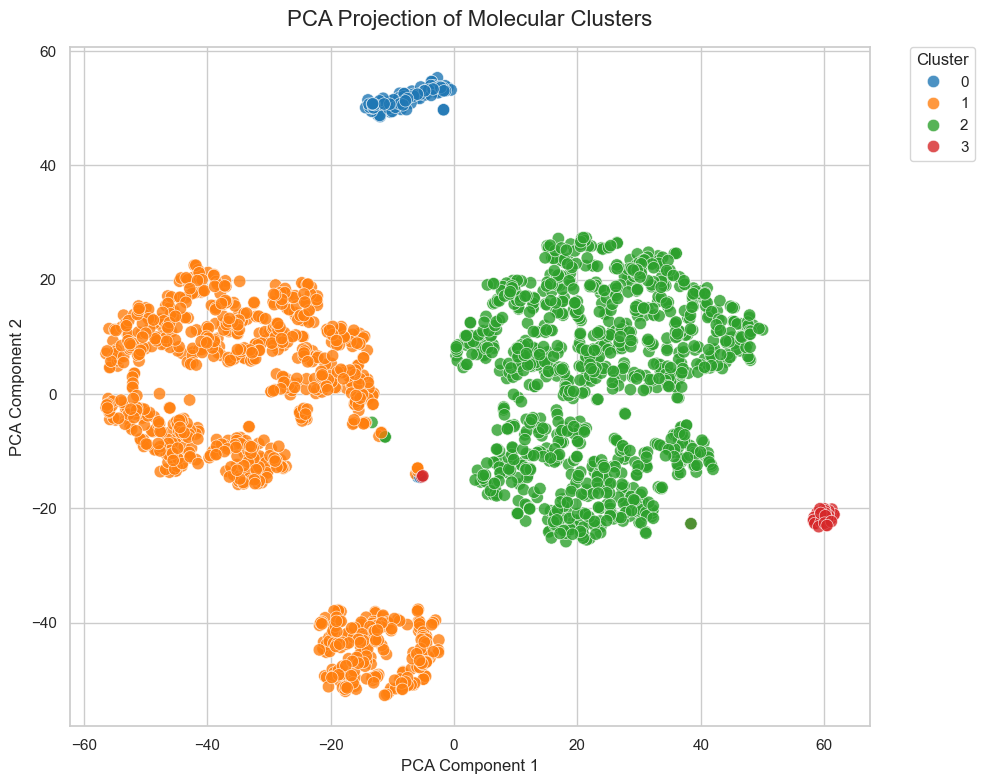


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [16]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['euclidean_riemann'], num_clusters=4)

In [17]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 3, 'data': 'structure…

- riemann makes clear cluster with aromatic structures when using 2 clusters
- 5 clusters:
    - cluster 0: cyclic (or acyclic) no functional groups. fairly complex molecules
    - cluster 1: aromatic
    - cluster 2: a lot of functional groups. many alcohol. many containing flour.
    - cluster 3: rings, containing nitrogen. many phenol groups. many amine. 
    - cluster 4: large diverse cluster. 

Using precomputed euclidean distance matrix (Shape: (2000, 2000))

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,81,"[""qm9_3"", ""qm9_12"", ""qm9_28"", ""qm9_452"", ""qm9_535"", ""qm9_702"", ""qm9_1112"", ""qm9_1508"", ""qm9_2194"", ""qm9_2822"", ""qm9_5084"", ""qm9_5526"", ""qm9_7229"", ""qm9_7676"", ""qm9_10993"", ""qm9_16930"", ""qm9_17132"", ""qm9_18727"", ""qm9_18789"", ""qm9_19286"", ""qm9_33435"", ""qm9_34001"", ""qm9_36585"", ""qm9_37880"", ""qm9_38981"", ""qm9_40880"", ""qm9_55077"", ""qm9_55947"", ""qm9_56039"", ""qm9_57241"", ""qm9_58249"", ""qm9_58476"", ""qm9_58498"", ""qm9_58700"", ""qm9_61109"", ""qm9_62239"", ""qm9_62382"", ""qm9_62679"", ""qm9_65224"", ""qm9_65743"", ""qm9_68678"", ""qm9_70013"", ""qm9_70679"", ""qm9_72560"", ""qm9_72596"", ""qm9_73151"", ""qm9_73378"", ""qm9_73443"", ""qm9_74746"", … ""qm9_117104""]","""[H]C#C[H]""",81
1,677,"[""qm9_2"", ""qm9_5"", ""qm9_10"", ""qm9_27"", ""qm9_200"", ""qm9_296"", ""qm9_467"", ""qm9_555"", ""qm9_596"", ""qm9_664"", ""qm9_673"", ""qm9_691"", ""qm9_929"", ""qm9_1139"", ""qm9_1368"", ""qm9_1390"", ""qm9_1421"", ""qm9_1713"", ""qm9_1914"", ""qm9_1938"", ""qm9_1942"", ""qm9_2044"", ""qm9_2126"", ""qm9_2199"", ""qm9_2237"", ""qm9_2265"", ""qm9_2272"", ""qm9_2276"", ""qm9_2293"", ""qm9_2371"", ""qm9_2593"", ""qm9_2912"", ""qm9_3086"", ""qm9_3266"", ""qm9_3286"", ""qm9_3564"", ""qm9_4500"", ""qm9_5041"", ""qm9_5571"", ""qm9_5576"", ""qm9_6018"", ""qm9_6076"", ""qm9_6212"", ""qm9_6354"", ""qm9_6743"", ""qm9_6835"", ""qm9_6901"", ""qm9_7152"", ""qm9_7212"", … ""qm9_121282""]","""[H]O[H]""",677
2,213,"[""qm9_9"", ""qm9_24"", ""qm9_30"", ""qm9_85"", ""qm9_110"", ""qm9_190"", ""qm9_319"", ""qm9_475"", ""qm9_478"", ""qm9_481"", ""qm9_728"", ""qm9_740"", ""qm9_750"", ""qm9_1631"", ""qm9_3487"", ""qm9_3589"", ""qm9_3627"", ""qm9_3646"", ""qm9_3798"", ""qm9_4211"", ""qm9_4511"", ""qm9_5053"", ""qm9_5186"", ""qm9_5320"", ""qm9_5417"", ""qm9_5454"", ""qm9_8148"", ""qm9_8459"", ""qm9_8515"", ""qm9_9650"", ""qm9_9675"", ""qm9_10941"", ""qm9_11743"", ""qm9_11756"", ""qm9_14650"", ""qm9_14750"", ""qm9_15770"", ""qm9_15788"", ""qm9_17350"", ""qm9_17601"", ""qm9_18654"", ""qm9_18811"", ""qm9_18856"", ""qm9_18947"", ""qm9_19342"", ""qm9_19753"", ""qm9_20013"", ""qm9_20052"", ""qm9_20100"", … ""qm9_130798""]","""[H]C([H])([H])C#N""",213
3,990,"[""qm9_11"", ""qm9_26"", ""qm9_33"", ""qm9_35"", ""qm9_57"", ""qm9_104"", ""qm9_109"", ""qm9_165"", ""qm9_170"", ""qm9_172"", ""qm9_180"", ""qm9_313"", ""qm9_371"", ""qm9_415"", ""qm9_431"", ""qm9_496"", ""qm9_683"", ""qm9_704"", ""qm9_717"", ""qm9_763"", ""qm9_764"", ""qm9_765"", ""qm9_769"", ""qm9_827"", ""qm9_859"", ""qm9_876"", ""qm9_888"", ""qm9_992"", ""qm9_1045"", ""qm9_1121"", ""qm9_1322"", ""qm9_1326"", ""qm9_1434"", ""qm9_1471"", ""qm9_1514"", ""qm9_1571"", ""qm9_1654"", ""qm9_1800"", ""qm9_2185"", ""qm9_2307"", ""qm9_2359"", ""qm9_2536"", ""qm9_2587"", ""qm9_2647"", ""qm9_2766"", ""qm9_2913"", ""qm9_3035"", ""qm9_3191"", ""qm9_3574"", … ""qm9_129120""]","""[H]C(=O)N([H])[H]""",990
4,39,"[""qm9_173"", ""qm9_812"", ""qm9_4127"", ""qm9_23238"", ""qm9_23253"", ""qm9_23285"", ""qm9_23349"", ""qm9_23364"", ""qm9_23372"", ""qm9_23391"", ""qm9_23457"", ""qm9_23489"", ""qm9_23518"", ""qm9_129267"", ""qm9_129319"", ""qm9_129449"", ""qm9_129466"", ""qm9_129516"", ""qm9_129577"", ""qm9_129594"", ""qm9_129739"", ""qm9_129756"", ""qm9_129884"", ""qm9_130005"", ""qm9_130029"", ""qm9_130048"", ""qm9_130074"", ""qm9_130181"", ""qm9_130224"", ""qm9_130302"", ""qm9_130314"", ""qm9_130325"", ""qm9_130357"", ""qm9_130383"", ""qm9_130507"", ""qm9_130621"", ""qm9_130641"", ""qm9_130771"", ""qm9_130787""]","""N1=NON=N1""",39



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,81,8.444444,0.779101,0.09296,0.127939,0.0,2.315343,7.215788,30.875926,-10395.577857,-6.606891,0.608964,18.604938,117.70084,0.493827,0.876543,5.160494,6.037037,39.469136,1.259213
1,677,8.703102,0.752717,0.075625,0.171658,0.0,2.508987,7.199072,32.335284,-10974.595408,-6.625964,0.573159,19.088626,122.204254,0.415066,0.872969,5.28065,6.395864,40.187592,1.259925
2,213,8.553991,0.696457,0.182378,0.121166,0.0,2.773484,6.658869,29.435629,-10741.627363,-6.455282,0.203638,17.032864,118.481362,0.41784,1.704225,3.868545,6.173709,34.765258,1.263495
3,990,8.69798,0.693818,0.142464,0.162135,0.001584,2.791825,6.611729,30.935023,-11144.35521,-6.538445,0.073298,17.657576,121.61014,0.438384,1.548485,4.075758,6.313131,35.986869,1.261741
4,39,8.615385,0.526353,0.21104,0.080983,0.181624,2.876264,6.382256,27.704026,-13103.951047,-6.959068,-0.576533,13.410256,125.405954,0.384615,2.897436,1.307692,5.74359,24.538462,1.277519


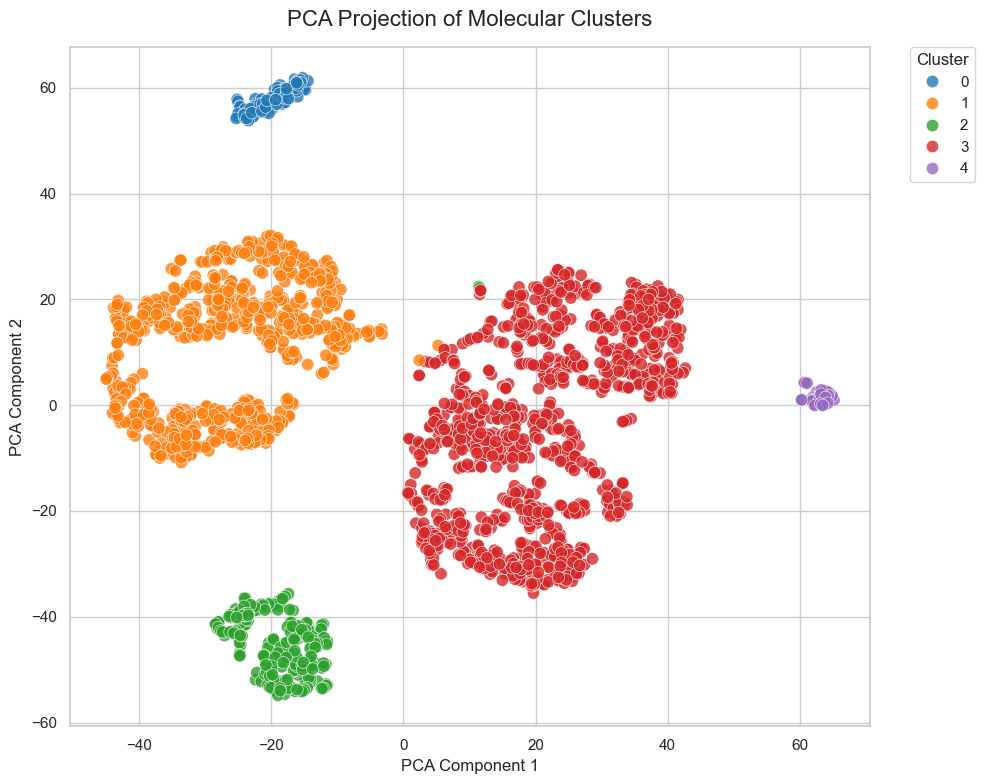


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [20]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['affine_riemann'], num_clusters=5)

In [21]:
chemiscope.show_input(output_path)


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 3, 'data': 'structure…

5 clusters:
- cluster 0: many flour. majority aromatic with phenol group in the middle of the cluster. on the left: acyclic flour with functional groups. on the right: aromatic phenol.
- cluster 1: many ether and ketone in top. on the right: alcohol. middle: cyclic ether.
- cluster 2: cyclic/acyclic no functional groups. almost only carbon and hydrogen.
- cluster 3: aromatic. few functional groups.
- cluster 4: acyclic. top: many functional groups and flour. bottom: cyclic ether some alcohol. left acyclic alcohol. right: like left on cluster 0.

- Persona,Cluster,Dominant Chemistry,Defining Statistic
- The Hydrocarbon Core,0,Pure or nearly pure hydrocarbons (Alkanes/Alkenes).,99.6% Carbon ratio; highest sp3 count (4.95).
- The Oxygenated Group,1,"Alcohols, Ethers, and Ketones.",24.7% Oxygen ratio; 0% Nitrogen.
- The Nitrogenated Group,2,Amines and Nitriles.,31.2% Nitrogen ratio; 0% Oxygen.
- The Heterofunctional Group,3,"Amides, Nitro-groups, or complex N+O structures.",Mixed N (20%) and O (20%); highest sp2 (1.51).

# Earths movers distance

Using precomputed euclidean distance matrix (Shape: (2000, 2000))

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1114,"[""qm9_5"", ""qm9_9"", ""qm9_10"", ""qm9_11"", ""qm9_24"", ""qm9_26"", ""qm9_28"", ""qm9_30"", ""qm9_33"", ""qm9_35"", ""qm9_85"", ""qm9_109"", ""qm9_110"", ""qm9_180"", ""qm9_200"", ""qm9_313"", ""qm9_319"", ""qm9_431"", ""qm9_475"", ""qm9_478"", ""qm9_481"", ""qm9_496"", ""qm9_535"", ""qm9_555"", ""qm9_673"", ""qm9_683"", ""qm9_702"", ""qm9_717"", ""qm9_728"", ""qm9_740"", ""qm9_750"", ""qm9_763"", ""qm9_764"", ""qm9_769"", ""qm9_827"", ""qm9_859"", ""qm9_876"", ""qm9_888"", ""qm9_929"", ""qm9_992"", ""qm9_1139"", ""qm9_1322"", ""qm9_1326"", ""qm9_1368"", ""qm9_1390"", ""qm9_1434"", ""qm9_1508"", ""qm9_1514"", ""qm9_1571"", … ""qm9_130641""]","""[H]C([H])=O""",1114
1,886,"[""qm9_2"", ""qm9_3"", ""qm9_12"", ""qm9_27"", ""qm9_57"", ""qm9_104"", ""qm9_165"", ""qm9_170"", ""qm9_172"", ""qm9_173"", ""qm9_190"", ""qm9_296"", ""qm9_371"", ""qm9_415"", ""qm9_452"", ""qm9_467"", ""qm9_596"", ""qm9_664"", ""qm9_691"", ""qm9_704"", ""qm9_765"", ""qm9_812"", ""qm9_1045"", ""qm9_1112"", ""qm9_1121"", ""qm9_1421"", ""qm9_1471"", ""qm9_1713"", ""qm9_2044"", ""qm9_2126"", ""qm9_2185"", ""qm9_2237"", ""qm9_2276"", ""qm9_2293"", ""qm9_2307"", ""qm9_2359"", ""qm9_2536"", ""qm9_2647"", ""qm9_2912"", ""qm9_2913"", ""qm9_3035"", ""qm9_3086"", ""qm9_3191"", ""qm9_3266"", ""qm9_3286"", ""qm9_3487"", ""qm9_3564"", ""qm9_3574"", ""qm9_3626"", … ""qm9_130798""]","""[H]O[H]""",886



Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,avg_element_ratio_C,avg_element_ratio_N,avg_element_ratio_O,avg_element_ratio_F,avg_mu,avg_gap,avg_cv,avg_u0,avg_homo,avg_lumo,avg_num_atoms,avg_total_mass,avg_num_sp_carbons,avg_num_sp2_carbons,avg_num_sp3_carbons,avg_main_chain_length,avg_raw_token_count,avg_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1114,8.665171,0.69512,0.140519,0.159241,0.005119,2.78462,6.66038,31.138144,-11127.790495,-6.568003,0.092379,17.698384,121.356696,0.448833,1.61939,3.978456,6.397666,35.970377,1.259161
1,886,8.681716,0.738245,0.101925,0.156502,0.003328,2.540511,7.055808,31.241494,-10956.452217,-6.572935,0.482956,18.44921,121.440282,0.405192,0.978555,5.046275,6.18623,38.738149,1.264482


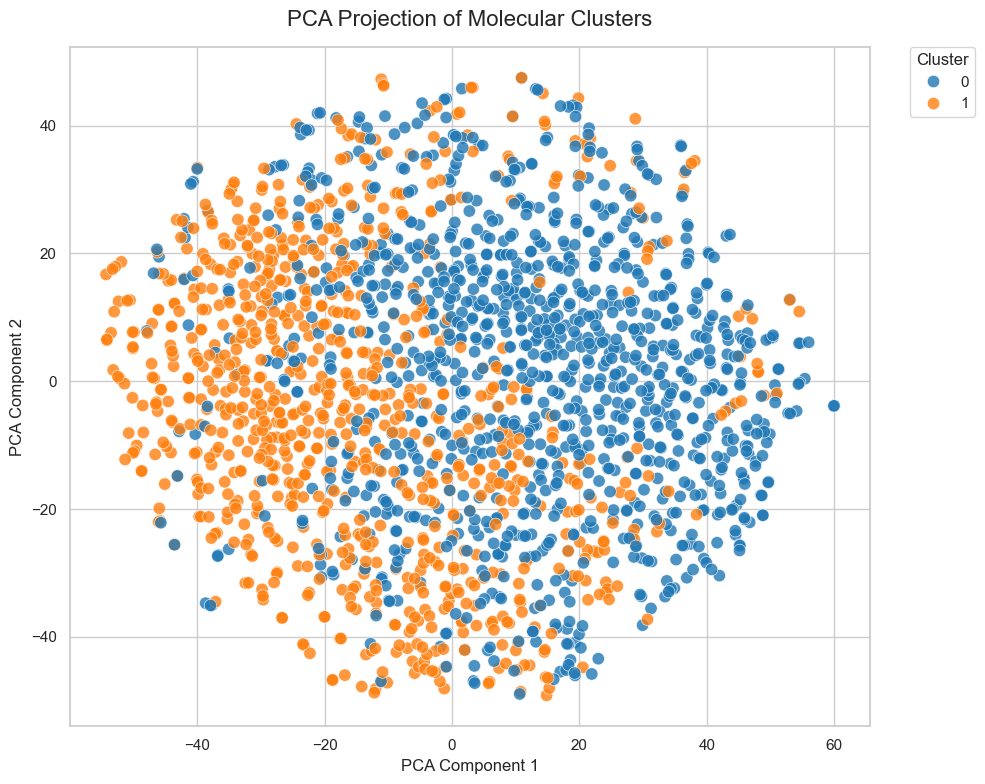


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [22]:
summary_table, profile_table, output_path = make_clustering(frames, dist_matrix = distance_matrices['wasserstein'], num_clusters=2)

In [23]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 3, 'data': 'structure…

2 clusters:
- cluster 0: not very well seperated. no idea.

# Persistent homology

Using precomputed euclidean distance matrix (Shape: (2000, 2000))


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,101,"[""qm9_21"", ""qm9_39"", ""qm9_40"", ""qm9_42"", ""qm9_44"", ""qm9_48"", ""qm9_61"", ""qm9_67"", ""qm9_70"", ""qm9_71"", ""qm9_118"", ""qm9_150"", ""qm9_225"", ""qm9_229"", ""qm9_233"", ""qm9_235"", ""qm9_236"", ""qm9_317"", ""qm9_325"", ""qm9_329"", ""qm9_330"", ""qm9_334"", ""qm9_335"", ""qm9_343"", ""qm9_344"", ""qm9_356"", ""qm9_357"", ""qm9_369"", ""qm9_371"", ""qm9_372"", ""qm9_379"", ""qm9_391"", ""qm9_392"", ""qm9_394"", ""qm9_395"", ""qm9_399"", ""qm9_400"", ""qm9_414"", ""qm9_467"", ""qm9_477"", ""qm9_485"", ""qm9_492"", ""qm9_495"", ""qm9_496"", ""qm9_498"", ""qm9_499"", ""qm9_505"", ""qm9_532"", ""qm9_542"", … ""qm9_1884""]","""[H]OC([H])(C([H])([H])[H])C([H])([H])[H]""",101
1,47,"[""qm9_50"", ""qm9_51"", ""qm9_52"", ""qm9_161"", ""qm9_162"", ""qm9_163"", ""qm9_165"", ""qm9_167"", ""qm9_168"", ""qm9_169"", ""qm9_170"", ""qm9_171"", ""qm9_172"", ""qm9_182"", ""qm9_183"", ""qm9_205"", ""qm9_212"", ""qm9_431"", ""qm9_712"", ""qm9_733"", ""qm9_741"", ""qm9_745"", ""qm9_749"", ""qm9_751"", ""qm9_755"", ""qm9_757"", ""qm9_758"", ""qm9_759"", ""qm9_760"", ""qm9_761"", ""qm9_762"", ""qm9_763"", ""qm9_764"", ""qm9_768"", ""qm9_769"", ""qm9_771"", ""qm9_772"", ""qm9_774"", ""qm9_775"", ""qm9_776"", ""qm9_877"", ""qm9_888"", ""qm9_903"", ""qm9_987"", ""qm9_989"", ""qm9_997"", ""qm9_2072""]","""[H]C1=NC([H])=C([H])N1[H]""",47
2,117,"[""qm9_93"", ""qm9_94"", ""qm9_156"", ""qm9_158"", ""qm9_166"", ""qm9_184"", ""qm9_195"", ""qm9_206"", ""qm9_439"", ""qm9_448"", ""qm9_544"", ""qm9_633"", ""qm9_660"", ""qm9_661"", ""qm9_668"", ""qm9_682"", ""qm9_698"", ""qm9_823"", ""qm9_826"", ""qm9_828"", ""qm9_832"", ""qm9_833"", ""qm9_836"", ""qm9_837"", ""qm9_839"", ""qm9_853"", ""qm9_854"", ""qm9_856"", ""qm9_857"", ""qm9_859"", ""qm9_860"", ""qm9_867"", ""qm9_883"", ""qm9_889"", ""qm9_907"", ""qm9_908"", ""qm9_910"", ""qm9_912"", ""qm9_918"", ""qm9_923"", ""qm9_939"", ""qm9_942"", ""qm9_944"", ""qm9_945"", ""qm9_948"", ""qm9_949"", ""qm9_951"", ""qm9_955"", ""qm9_966"", … ""qm9_2232""]","""[H]C([H])([H])C1([H])C([H])([H])OC1([H])[H]""",117
3,130,"[""qm9_60"", ""qm9_69"", ""qm9_73"", ""qm9_83"", ""qm9_84"", ""qm9_92"", ""qm9_97"", ""qm9_99"", ""qm9_101"", ""qm9_115"", ""qm9_117"", ""qm9_124"", ""qm9_133"", ""qm9_134"", ""qm9_146"", ""qm9_148"", ""qm9_149"", ""qm9_175"", ""qm9_179"", ""qm9_217"", ""qm9_246"", ""qm9_259"", ""qm9_261"", ""qm9_262"", ""qm9_263"", ""qm9_278"", ""qm9_297"", ""qm9_352"", ""qm9_354"", ""qm9_355"", ""qm9_360"", ""qm9_365"", ""qm9_368"", ""qm9_370"", ""qm9_389"", ""qm9_390"", ""qm9_398"", ""qm9_410"", ""qm9_415"", ""qm9_416"", ""qm9_500"", ""qm9_519"", ""qm9_521"", ""qm9_523"", ""qm9_530"", ""qm9_531"", ""qm9_551"", ""qm9_564"", ""qm9_567"", … ""qm9_1969""]","""[H]C#CC([H])(C([H])([H])[H])C([H])([H])[H]""",130
4,140,"[""qm9_53"", ""qm9_79"", ""qm9_129"", ""qm9_510"", ""qm9_514"", ""qm9_1056"", ""qm9_1059"", ""qm9_1063"", ""qm9_1064"", ""qm9_1073"", ""qm9_1093"", ""qm9_1094"", ""qm9_1096"", ""qm9_1103"", ""qm9_1135"", ""qm9_1144"", ""qm9_1145"", ""qm9_1147"", ""qm9_1148"", ""qm9_1150"", ""qm9_1153"", ""qm9_1154"", ""qm9_1156"", ""qm9_1166"", ""qm9_1208"", ""qm9_1209"", ""qm9_1211"", ""qm9_1216"", ""qm9_1217"", ""qm9_1218"", ""qm9_1231"", ""qm9_1234"", ""qm9_1236"", ""qm9_1237"", ""qm9_1243"", ""qm9_1244"", ""qm9_1246"", ""qm9_1263"", ""qm9_1265"", ""qm9_1275"", ""qm9_1281"", ""qm9_1282"", ""qm9_1290"", ""qm9_1297"", ""qm9_1298"", ""qm9_1304"", ""qm9_1319"", ""qm9_1324"", ""qm9_1390"", … ""qm9_2233""]","""[H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",140
5,87,"[""qm9_797"", ""qm9_1102"", ""qm9_1108"", ""qm9_1276"", ""qm9_1307"", ""qm9_1310"", ""qm9_1311"", ""qm9_1315"", ""qm9_1316"", ""qm9_1318"", ""qm9_1660"", ""qm9_1666"", ""qm9_1672"", ""qm9_1675"", ""qm9_1805"", ""qm9_1806"", ""qm9_1808"", ""qm9_1812"", ""qm9_1813"", ""qm9_1819"", ""qm9_1826"", ""qm9_1831"", ""qm9_1834"", ""qm9_1835"", ""qm9


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo,avg_num_atoms,var_num_atoms,avg_total_mass,var_total_mass,avg_num_sp_carbons,var_num_sp_carbons,avg_num_sp2_carbons,var_num_sp2_carbons,avg_num_sp3_carbons,var_num_sp3_carbons,avg_main_chain_length,var_main_chain_length,avg_raw_token_count,var_raw_token_count,avg_avg_bond_length,var_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,101,6.178218,0.587921,0.639604,0.022406,0.130905,0.018702,0.229491,0.018664,0.0,0.0,2.878933,2.433968,7.00351,1.499228,22.990505,6.468915,-8334.795744,2.2018e6,-7.165782,0.282606,-0.162137,1.452346,12.0,0.0,87.499802,118.783405,0.920792,1.253663,0.831683,0.581386,2.148515,0.707723,5.366337,0.634455,22.39604,2.321584,1.237406,0.000321
1,47,5.87234,0.418131,0.391388,0.019714,0.404863,0.041154,0.203749,0.021661,0.0,0.0,2.929996,2.013993,6.553081,0.408709,15.306702,5.931985,-8434.429656,1.5391e6,-7.267061,0.709267,-0.714096,0.867522,8.382979,0.80666,82.656255,89.526113,0.06383,0.061055,2.148936,0.651249,0.085106,0.079556,4.191489,0.375578,13.06383,5.017576,1.259682,0.000255
2,117,6.811966,0.2402,0.643468,0.009465,0.149451,0.018164,0.207082,0.015686,0.0,0.0,2.550082,1.600361,6.597598,0.959388,22.541667,4.633827,-9065.86937,1.0874e6,-6.282667,0.754289,0.314908,1.094756,12.957265,0.213675,95.752436,54.454672,0.068376,0.115974,2.273504,2.027999,2.017094,1.741085,5.239316,0.407751,24.666667,3.862069,1.255365,0.000309
3,130,6.4,0.505426,0.643333,0.018498,0.139084,0.015467,0.217582,0.015724,0.0,0.0,3.05413,3.148807,7.183597,1.755997,24.485062,7.053858,-8580.74751,1.8545e6,-7.066713,0.268287,0.116883,1.471388,13.0,0.0,90.979508,100.488956,0.830769,1.118426,0.830769,0.560286,2.415385,0.756351,5.6,0.644961,24.846154,2.518784,1.236127,0.000224
4,140,6.942857,0.097431,0.760544,0.012266,0.044218,0.00768,0.195238,0.011193,0.0,0.0,2.231936,1.067326,7.684787,1.291015,29.247993,3.364883,-8873.835059,724849.785872,-6.792973,0.17158,0.891678,1.073653,17.0,0.0,99.582086,25.200861,0.471429,0.682631,0.4,0.241727,4.4,0.443165,6.0,0.532374,35.007143,1.647431,1.232952,0.000223
5,87,7.0,0.0,0.802956,0.007234,0.021346,0.004522,0.175698,0.005553,0.0,0.0,1.61801,0.500781,8.064079,1.037931,26.574011,1.233904,-8725.370005,258720.294857,-6.544839,0.090151,1.51924,0.820023,17.0,0.0,99.360034,4.102107,0.0,0.0,0.574713,0.758888,5.045977,0.602513,5.413793,0.268645,36.034483,1.010425,1.252622,0.000097
6,59,6.372881,0.341321,0.735674,0.015105,0.090799,0.009197,0.173527,0.008993,0.0,0.0,2.274264,1.164396,7.911042,1.188481,22.149712,5.732587,-8131.747534,1.2907e6,-6.734126,0.220675,1.176823,1.115365,14.0,0.0,89.911864,70.166417,0.135593,0.119229,0.355932,0.302162,4.152542,0.614261,4.983051,0.361777,29.220339,1.795441,1.262697,0.000229
7,122,6.54918,0.266156,0.732826,0.018483,0.094555,0.008059,0.172619,0.011458,0.0,0.0,2.501114,3.288941,8.049619,1.244791,27.20359,5.828382,-8388.256136,1.3711e6,-6.834073,0.249573,1.215256,0.92123,16.0,0.0,94.041189,63.220369,0.303279,0.361807,0.42623,0.263108,4.02459,0.734928,5.770492,0.57499,32.983607,2.049316,1.232779,0.00023
8,55,5.8,1.051852,0.605498,0.023775,0.13355,0.014041,0.260952,0.01909,0.0,0.0,3.012536,3.524059,6.595496,2.45645,20.265873,10.177324,-8000.529483,3.0114e6,-7.334903,0.366713,-0.739556,2.532688,10.018182,0.018182,81.6758,188.117397,1.163636,1.546801,1.054545,0.793266,1.236364,0.961616,5.163636,0.694949,17.436364,3.472727,1.23868,0.000578


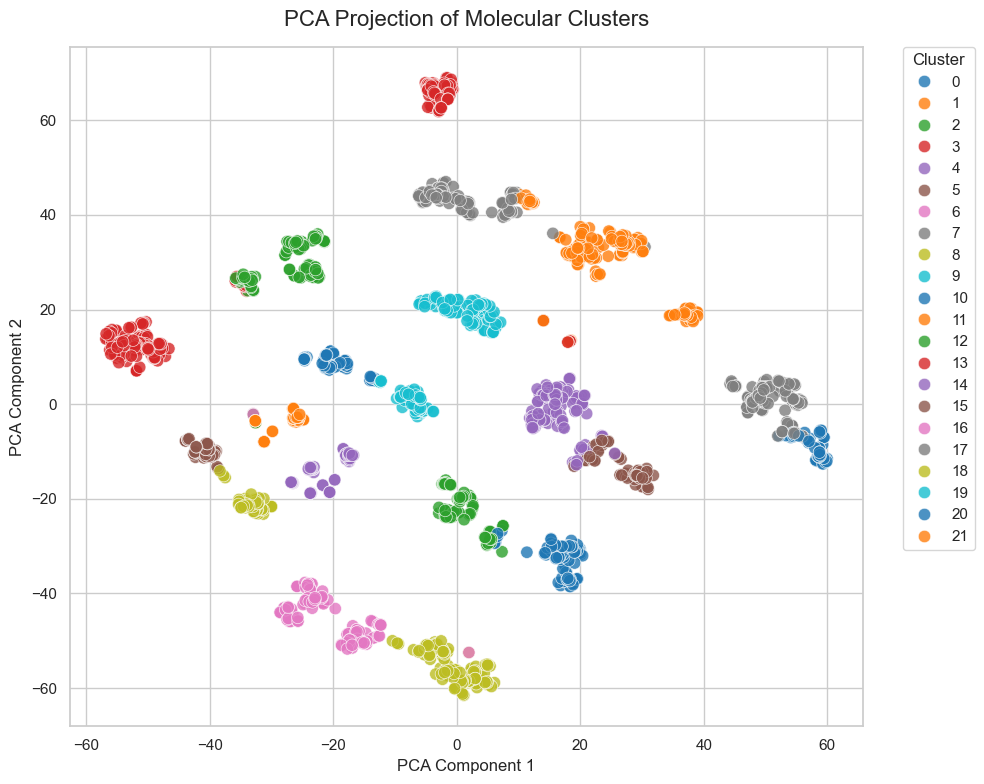


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(
    frames, 
    dist_matrix=distance_matrices['ph_bottleneck'],
    num_clusters=22
)

In [ ]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

22 cluster - very well seperated:
- cluster 0: acyclic. amide.
- cluster 1: cyclic. amide, ether. complicated looking molecules.
- cluster 2: acyclic. amine. ether. alcohol.
- cluster 3: cyclic. alcohol. top right: acyclic no functional groups.
- cluster 4: either aromatic or cyclic. amine, phenol. cyclic with amide, ketone, ester, ether.
- cluster 5: middle: aromatic. top cyclic ether. bottom cyclic ketone and alcohol, ester ether.
- cluster 6: acyclic all different kinds of functional groups.
- cluster 7: acyclic, on the right cyclic
- cluster 8: top: aromatic, middle right: cyclic many functional groups. left: cyclic alcohol.

Using precomputed euclidean distance matrix (Shape: (2000, 2000))


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,156,"[""qm9_60"", ""qm9_69"", ""qm9_73"", ""qm9_83"", ""qm9_84"", ""qm9_92"", ""qm9_93"", ""qm9_94"", ""qm9_97"", ""qm9_99"", ""qm9_101"", ""qm9_115"", ""qm9_117"", ""qm9_124"", ""qm9_133"", ""qm9_134"", ""qm9_146"", ""qm9_148"", ""qm9_149"", ""qm9_156"", ""qm9_158"", ""qm9_175"", ""qm9_179"", ""qm9_217"", ""qm9_246"", ""qm9_259"", ""qm9_261"", ""qm9_262"", ""qm9_263"", ""qm9_278"", ""qm9_297"", ""qm9_352"", ""qm9_354"", ""qm9_355"", ""qm9_360"", ""qm9_365"", ""qm9_368"", ""qm9_370"", ""qm9_389"", ""qm9_390"", ""qm9_398"", ""qm9_410"", ""qm9_415"", ""qm9_416"", ""qm9_439"", ""qm9_500"", ""qm9_519"", ""qm9_521"", ""qm9_523"", … ""qm9_2200""]","""[H]C#CC([H])(C([H])([H])[H])C([H])([H])[H]""",156
1,91,"[""qm9_0"", ""qm9_1"", ""qm9_2"", ""qm9_3"", ""qm9_4"", ""qm9_5"", ""qm9_6"", ""qm9_7"", ""qm9_9"", ""qm9_10"", ""qm9_11"", ""qm9_13"", ""qm9_16"", ""qm9_18"", ""qm9_19"", ""qm9_24"", ""qm9_25"", ""qm9_27"", ""qm9_30"", ""qm9_31"", ""qm9_32"", ""qm9_33"", ""qm9_35"", ""qm9_36"", ""qm9_37"", ""qm9_52"", ""qm9_55"", ""qm9_56"", ""qm9_58"", ""qm9_59"", ""qm9_88"", ""qm9_90"", ""qm9_103"", ""qm9_105"", ""qm9_106"", ""qm9_107"", ""qm9_108"", ""qm9_109"", ""qm9_110"", ""qm9_111"", ""qm9_113"", ""qm9_137"", ""qm9_139"", ""qm9_140"", ""qm9_143"", ""qm9_162"", ""qm9_163"", ""qm9_165"", ""qm9_166"", … ""qm9_1338""]","""[H]C([H])([H])[H]""",91
2,162,"[""qm9_213"", ""qm9_218"", ""qm9_221"", ""qm9_227"", ""qm9_243"", ""qm9_248"", ""qm9_252"", ""qm9_254"", ""qm9_265"", ""qm9_270"", ""qm9_283"", ""qm9_285"", ""qm9_286"", ""qm9_287"", ""qm9_289"", ""qm9_292"", ""qm9_293"", ""qm9_302"", ""qm9_303"", ""qm9_304"", ""qm9_306"", ""qm9_308"", ""qm9_348"", ""qm9_361"", ""qm9_375"", ""qm9_385"", ""qm9_386"", ""qm9_401"", ""qm9_405"", ""qm9_406"", ""qm9_407"", ""qm9_423"", ""qm9_424"", ""qm9_446"", ""qm9_449"", ""qm9_452"", ""qm9_458"", ""qm9_461"", ""qm9_464"", ""qm9_468"", ""qm9_507"", ""qm9_512"", ""qm9_524"", ""qm9_537"", ""qm9_538"", ""qm9_539"", ""qm9_540"", ""qm9_552"", ""qm9_554"", … ""qm9_2229""]","""[H]C#CC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",162
3,148,"[""qm9_21"", ""qm9_39"", ""qm9_40"", ""qm9_42"", ""qm9_44"", ""qm9_46"", ""qm9_48"", ""qm9_61"", ""qm9_67"", ""qm9_70"", ""qm9_71"", ""qm9_118"", ""qm9_150"", ""qm9_225"", ""qm9_229"", ""qm9_233"", ""qm9_235"", ""qm9_236"", ""qm9_298"", ""qm9_300"", ""qm9_317"", ""qm9_325"", ""qm9_329"", ""qm9_330"", ""qm9_334"", ""qm9_335"", ""qm9_343"", ""qm9_344"", ""qm9_356"", ""qm9_357"", ""qm9_369"", ""qm9_371"", ""qm9_372"", ""qm9_379"", ""qm9_391"", ""qm9_392"", ""qm9_394"", ""qm9_395"", ""qm9_399"", ""qm9_400"", ""qm9_412"", ""qm9_414"", ""qm9_418"", ""qm9_420"", ""qm9_427"", ""qm9_428"", ""qm9_432"", ""qm9_433"", ""qm9_436"", … ""qm9_2204""]","""[H]OC([H])(C([H])([H])[H])C([H])([H])[H]""",148
4,259,"[""qm9_53"", ""qm9_79"", ""qm9_129"", ""qm9_220"", ""qm9_223"", ""qm9_264"", ""qm9_291"", ""qm9_358"", ""qm9_383"", ""qm9_384"", ""qm9_510"", ""qm9_514"", ""qm9_534"", ""qm9_535"", ""qm9_536"", ""qm9_580"", ""qm9_782"", ""qm9_789"", ""qm9_796"", ""qm9_797"", ""qm9_1056"", ""qm9_1059"", ""qm9_1062"", ""qm9_1063"", ""qm9_1064"", ""qm9_1073"", ""qm9_1074"", ""qm9_1091"", ""qm9_1092"", ""qm9_1093"", ""qm9_1094"", ""qm9_1096"", ""qm9_1102"", ""qm9_1103"", ""qm9_1108"", ""qm9_1135"", ""qm9_1144"", ""qm9_1145"", ""qm9_1147"", ""qm9_1148"", ""qm9_1150"", ""qm9_1153"", ""qm9_1154"", ""qm9_1156"", ""qm9_1166"", ""qm9_1208"", ""qm9_1209"", ""qm9_1211"", ""qm9_1213"", … ""qm9_2233""]","""[H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]""",259
5,129,"[""qm9_155"", ""qm9_177"", ""qm9_450"", ""qm9_453"", ""qm9_457"", ""qm9_801"", ""qm9_802"", ""qm9_804"", ""qm9_809"", ""qm9_811"", ""qm9_818"", ""qm9_819"", ""qm9_820"", ""qm9_824"", ""qm9_830"", ""qm9_847"", ""qm9_848"", ""qm9_849"", ""qm9_878"", ""qm9_879"", ""qm9_881"", ""qm9_904"", ""qm9_933"", ""qm9_935"", ""qm9_937"", ""qm9_940"", ""qm9_960"",


Cluster Size/Composition/QM Property Summary:


cluster,n_samples,avg_heavy_atom_count,var_heavy_atom_count,avg_element_ratio_C,var_element_ratio_C,avg_element_ratio_N,var_element_ratio_N,avg_element_ratio_O,var_element_ratio_O,avg_element_ratio_F,var_element_ratio_F,avg_mu,var_mu,avg_gap,var_gap,avg_cv,var_cv,avg_u0,var_u0,avg_homo,var_homo,avg_lumo,var_lumo,avg_num_atoms,var_num_atoms,avg_total_mass,var_total_mass,avg_num_sp_carbons,var_num_sp_carbons,avg_num_sp2_carbons,var_num_sp2_carbons,avg_num_sp3_carbons,var_num_sp3_carbons,avg_main_chain_length,var_main_chain_length,avg_raw_token_count,var_raw_token_count,avg_avg_bond_length,var_avg_bond_length
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,156,6.410256,0.514475,0.656349,0.018016,0.125977,0.014989,0.217674,0.015634,0.0,0.0,2.961549,2.907267,7.178486,1.776875,24.024981,7.942814,-8559.374887,1.8978e6,-7.030951,0.27691,0.147569,1.529263,13.0,0.0,90.949026,102.877582,0.730769,1.036725,0.820513,0.548222,2.615385,0.896278,5.474359,0.715467,25.128205,2.770554,1.241988,0.000393
1,91,4.879121,1.863004,0.524228,0.048219,0.229932,0.054092,0.215071,0.032326,0.030769,0.017265,2.666426,2.058742,7.096969,4.38442,15.158813,15.987911,-6950.717663,5.3622e6,-7.855449,0.961775,-0.75848,3.092686,7.549451,2.139194,68.902093,359.62737,0.934066,1.75116,1.0,0.755556,0.593407,0.4884,4.065934,1.040049,12.010989,11.099878,1.234512,0.003363
2,162,6.574074,0.258454,0.743827,0.017907,0.095018,0.007423,0.161155,0.010495,0.0,0.0,2.374685,2.924755,7.994638,1.247422,26.623204,6.279295,-8343.080138,1.3043e6,-6.793322,0.255033,1.201131,0.882212,16.0,0.0,94.039673,60.823925,0.240741,0.295721,0.469136,0.325128,4.135802,0.677095,5.67284,0.544475,33.209877,1.843877,1.237451,0.000257
3,148,6.222973,0.514571,0.645142,0.020474,0.12537,0.017889,0.229488,0.016294,0.0,0.0,2.757484,2.099298,6.999927,1.590063,21.997574,7.838767,-8374.400249,1.9382e6,-7.044274,0.300276,-0.044347,1.562549,12.0,0.0,87.965642,104.714385,0.668919,1.052905,0.912162,0.706518,2.385135,0.973111,5.128378,0.656876,22.891892,2.682111,1.248387,0.000537
4,259,6.926641,0.091497,0.774683,0.010227,0.045045,0.007174,0.180272,0.008744,0.0,0.0,2.049621,1.054765,7.860876,1.186523,28.376483,4.331267,-8751.11074,587241.155647,-6.707586,0.169861,1.153216,0.994204,17.123552,0.108707,99.102849,21.005462,0.266409,0.428751,0.471042,0.42067,4.621622,0.569453,5.80695,0.520727,35.741313,2.324294,1.23819,0.000279
5,129,6.953488,0.06032,0.714101,0.010687,0.116833,0.014956,0.169066,0.014472,0.0,0.0,2.242076,1.245328,7.110715,1.115744,24.624039,2.360626,-8893.266723,574234.029722,-6.324791,0.51813,0.785861,0.867265,15.116279,0.150436,98.070132,16.348046,0.03876,0.068798,1.581395,2.448401,3.341085,1.570252,5.426357,0.308987,30.449612,2.077519,1.250567,0.000249
6,155,6.754839,0.329116,0.727527,0.015202,0.072104,0.012369,0.200369,0.01407,0.0,0.0,2.402058,1.491011,7.096817,1.540846,26.82871,4.289518,-8741.091926,1.3147e6,-6.883023,0.164138,0.213618,1.287027,15.0,0.0,95.889581,65.088693,0.677419,1.012149,0.716129,0.464349,3.503226,0.52434,5.754839,0.601843,30.03871,2.271219,1.23906,0.000299
7,136,5.926471,0.794553,0.62437,0.020301,0.134961,0.016951,0.236992,0.017364,0.003676,0.001838,3.059532,2.185534,6.747763,2.499353,20.615471,7.649827,-8068.88439,2.3915e6,-7.266781,0.374156,-0.519217,2.22632,10.676471,0.220479,83.457502,145.957363,0.963235,1.294935,1.088235,0.940305,1.602941,0.863399,5.066176,0.699292,19.264706,4.136819,1.243872,0.000669
8,159,6.886792,0.101027,0.853848,0.0101,0.033094,0.004298,0.113058,0.008424,0.0,0.0,1.395862,0.989195,8.458189,0.986567,29.926704,5.157205,-8225.010527,627991.076535,-6.753387,0.249697,1.704887,0.653262,18.779874,0.198073,98.292635,25.888573,0.163522,0.264231,0.245283,0.312873,5.465409,0.490884,5.798742,0.490884,40.283019,2.115596,1.234443,0.00019


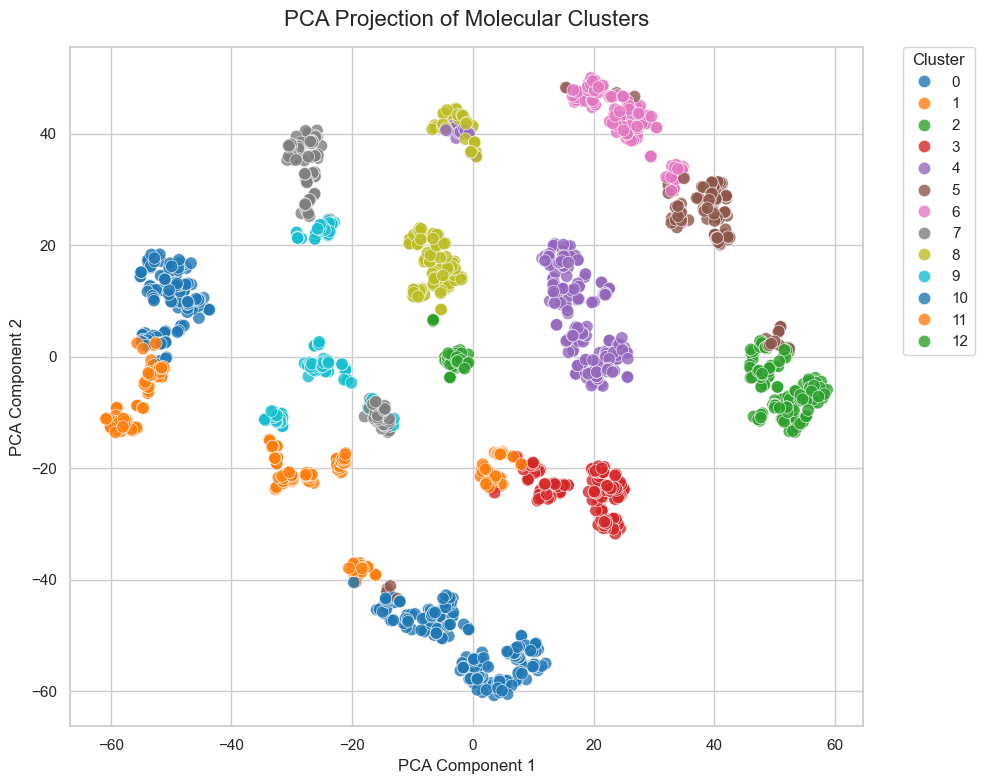


Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


In [ ]:
summary_table, profile_table, output_path = make_clustering(
    frames, 
    dist_matrix=distance_matrices['ph_sliced_wasserstein'],
    num_clusters=13,
)

In [ ]:

chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 5, 'data': 'structure…

10 clusters:
- cluster 0: dunno.
- cluster 1: acyclic one with halogen or aromatic containing phenol.
- cluster 2: cyclic ether or ketone.
- cluster 3: cyclic/acycic alcohol also other groups, amine, amide ether.
- cluster 4: acyclic, ether, amine amide.
- cluster 5: acyclic, amide, ester ether, alcohol.
- cluster 6: cyclic, amide, ether, alcohol, 
- cluster 7: cyclic, ether, alcohol
- cluster 8: small, aromatic, amine, phenol
- cluster 9: not well defined: some aromatic some cyclic with ether.